In [2]:
import tensorflow as tf
import numpy as np
import scipy
import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scipy.io import arff
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from scipy import interp
from itertools import cycle
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.optimizers import Adam


2024-04-06 09:30:43.094628: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-06 09:30:43.772105: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-06 09:30:45.197174: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-06 09:30:55.167163: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [55]:
#Sick:
#This is what I've already done to get my data into numeric format. Each class is a letter, A-Z, which I changed to numbers 1-26

# Load ARFF file
arff_file_path = 'sick_numeric2.arff'  
data, meta = arff.loadarff(arff_file_path)

# Convert data to a Pandas DataFrame
df = pd.DataFrame(data) 

Features = []
Classes = []
for i in range(3772):
    row_as_list = df.iloc[i].tolist()
    Classes.append(row_as_list[29])
    del row_as_list[29]
    Features.append(row_as_list)    

X0, y0 = Features, Classes
#
X0 = np.array(X0)
#convirt from bit strings to numeric values, where 1 is positive and -1 is negetive 
y0 = [0 if cls == b'negative' else 1 for cls in y0]
y0 = np.array(y0)

In [56]:
#letter:

# Load ARFF file
arff_file_path = 'dataset_6_letter.arff'  
data, meta = arff.loadarff(arff_file_path)

# Convert data to a Pandas DataFrame
df = pd.DataFrame(data)
#in this Pandas dataframe, the column lables are each of the features (16 in total), the final column is the class of letter, and everything 
#in the other columns is the feature value for each sample, ir observation. In order to utalize a pandas datafram, I need to create a 
#2D array (list of list) consisting of a list of every feature value in each sample: [[ft1,ft2,ft3...],[ft1,ft2,ft3...],...]
#This 2d array will be X. 
#y will be the class lable that correspods to each of the samples, or lists of features. y will be a array in the form [class1, class2, class3, ...].
#I now need to disect the data from the pandas dataframe. 

Features = []
Classes = []
for i in range(20000):
    row_as_list = df.iloc[i].tolist()
    Classes.append(row_as_list[16])
    del row_as_list[16]
    Features.append(row_as_list)    

X1, y1 = Features, Classes

X1 = np.array(X1)
# Convert bit strings to integers (1 for 'A', 2 for 'B', ..., 26 for 'Z')
y1 = [ord(cls) - 64 for cls in y1]
y1 = np.array(y1)

In [4]:
#Ionosphere

# Load ARFF file
arff_file_path = 'dataset_59_ionosphere.arff'  
data, meta = arff.loadarff(arff_file_path)

# Convert data to a Pandas DataFrame
df = pd.DataFrame(data)

Features = []
Classes = []
for i in range(351):
    row_as_list = df.iloc[i].tolist()
    Classes.append(row_as_list[34])
    del row_as_list[34]
    Features.append(row_as_list)    

X2, y2 = Features, Classes

X2 = np.array(X2)
# Convert bit strings to integers 1 and -1
y2 = [0 if cls == b'b' else 1 for cls in y2]
y2 = np.array(y2)
print(len(X2[0]))

34


In [9]:
#Solar Flare

# Load ARFF file
arff_file_path = 'solar.flare2.arff'  
data, meta = arff.loadarff(arff_file_path)

# Convert data to a Pandas DataFrame
df = pd.DataFrame(data)

#This solar flair data has 1066 samples a d 13 attributes (including the 3 classes to predict). All samples are from one active reigon of the sun.
#The attributes are:
# %  Attribute Information:
# %    1. Code for class (modified Zurich class)  (A,B,C,D,E,F,H) 
# %    2. Code for largest spot size              (X,R,S,A,H,K) 
# %    3. Code for spot distribution              (X,O,I,C) 
# %    4. Activity                                (1 = reduced, 2 = unchanged)
# %    5. Evolution                               (1 = decay, 2 = no growth, 
# %                                                3 = growth)
# %    6. Previous 24 hour flare activity code    (1 = nothing as big as an M1,
# %                                                2 = one M1,
# %                                                3 = more activity than one M1)
# %    7. Historically-complex                    (1 = Yes, 2 = No)
# %    8. Did region become historically complex  (1 = yes, 2 = no) 
# %       on this pass across the sun's disk
# %    9. Area                                    (1 = small, 2 = large)
# %   10. Area of the largest spot                (1 = <=5, 2 = >5)
# % 
# %  From all these predictors three classes of flares are predicted, which are 
# %  represented in the last three columns.
# % 
# %   11. C-class flares production by this region    Number  
# %       in the following 24 hours (common flares)
# %   12. M-class flares production by this region    Number
# %       in the following 24 hours (moderate flares)
# %   13. X-class flares production by this region    Number
# %       in the following 24 hours (severe flares)

#The three classes to predict (C-class, M-class, X-class) output numbers that indicate how many of those classes of flares were detected
#in the active riegon that is being viewed. So, it is possible for a signle sample of data to have numbers in all three classes. 

df['class'] = df['class'].astype('category') 
df['largest_spot_size'] = df['largest_spot_size'].astype('category')
df['spot_distribution'] = df['spot_distribution'].astype('category') 

df['new_class'] = df['class'].cat.codes
df['new_largest_spot_size'] = df['largest_spot_size'].cat.codes
df['new_spot_distribution'] = df['spot_distribution'].cat.codes

X_train_categorical = df[['class','largest_spot_size','spot_distribution']]

encoder = OneHotEncoder()
X_train_encoded = encoder.fit_transform(X_train_categorical)  # Encode categorical features

# Convert the encoded data to a DataFrame
X_train_encoded_df = pd.DataFrame(X_train_encoded.toarray(), columns=encoder.get_feature_names_out())

# Remove original categorical columns from the original DataFrame
df = df.drop(columns=X_train_categorical.columns)

# Concatenate the one-hot encoded DataFrame with the remaining columns in df
df = pd.concat([df, X_train_encoded_df], axis=1)

Features = []
Classes = []


for i in range(1066):
    row_as_list = df.iloc[i].tolist()
    Classes.append([row_as_list[26],row_as_list[27],row_as_list[28]])
    del row_as_list[28]
    del row_as_list[27]
    del row_as_list[26]
    # Append the remaining elements of row_as_list to Features
    Features.append(row_as_list)

X3, y3 = Features, Classes


#convirt bit strings to integers
#Note: be careful when doing this for k-nearest neighbor.
#If the original features were listed as letters to mean different types,
#changing them to numbers will tell the algorithm that some are closer to the others numerically.
#changing them to numeric type is not the same thing as One-hot encoading.
#Now that the first three columns have been one-hot encoded, I can change their bit string values to numeric ones. 

for j in range(1066):
    X3[j] = [0 if cls == b'0' else
         1 if cls == b'1' else 
         2 if cls == b'2' else 
         3 if cls == b'3' else 
         4 if cls == b'4' else 
         5 if cls == b'5' else 
         6 if cls == b'6' else 
         7 if cls == b'7' else cls 
         for cls in X3[j]]

#if the encoded bit strings are not turned into integer type before the data is converted to a Numpy array,
#all of the data that was integer type turns into bir strings. 
X3 = np.array(X3, dtype=int)

# Assuming y_Solarflare is a list of lists with one-hot encoded labels
y3 = np.array(y3)

Training with learning rate: 0.0001
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Learning rate: 0.0001 - Mean Accuracy: 95.17% - Mean F1 Score: 0.52


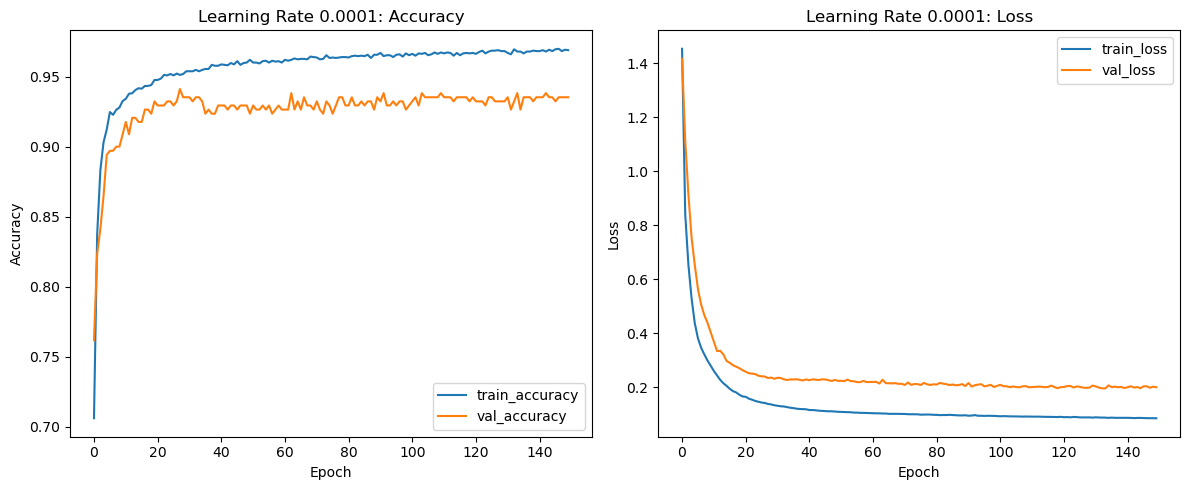

Training with learning rate: 0.001
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Learning rate: 0.001 - Mean Accuracy: 96.13% - Mean F1 Score: 0.67


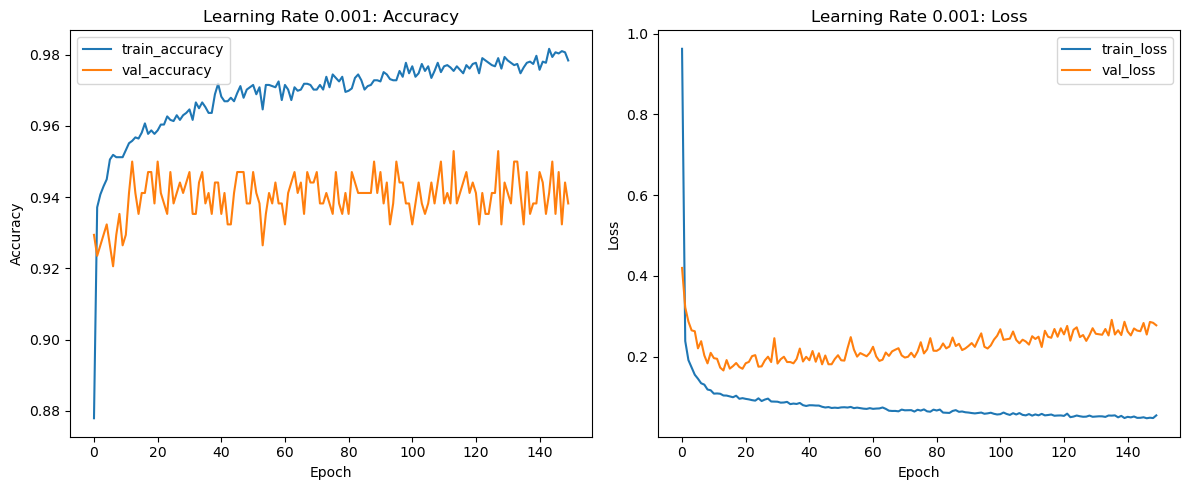

Training with learning rate: 0.01
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Learning rate: 0.01 - Mean Accuracy: 95.57% - Mean F1 Score: 0.64


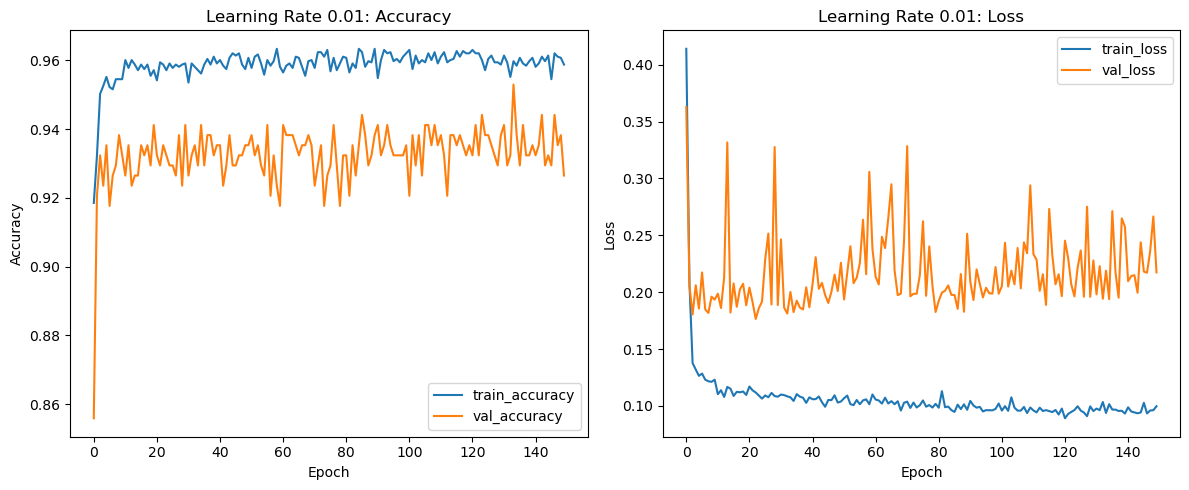

Summary Across Learning Rates:
Mean Accuracy: 95.62544822692871
Standard Deviation of Accuracy: 0.3914213671423283
Mean F1 Score: 0.6120068939118697
Standard Deviation of F1 Score: 0.06369241811759203


In [59]:
#Sick 

learning_rates = [0.0001, 0.001, 0.01]
final_accuracies0, final_F10 = [], []

for learning_rate in learning_rates:
    print(f"Training with learning rate: {learning_rate}")
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    accuracies, f1_scores = [], []

    # Initialize lists to collect metrics across all folds for averaging
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for train_index, test_index in kf.split(X0): 
        # Splitting the dataset
        X0_train, X0_test = X0[train_index], X0[test_index]
        y0_train, y0_test = y0[train_index], y0[test_index]

        # Model definition
        model = Sequential([
            Input(shape=(29,)), 
            Dense(12, activation='relu'),
            Dense(8, activation='relu'),
            Dense(1, activation='sigmoid')  # For binary classification
        ])
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

        # Training the model
        history = model.fit(X0_train, y0_train, validation_split=0.1, epochs=150, batch_size=10, verbose=0)

        _, accuracy = model.evaluate(X0_test, y0_test, verbose=0)
        predictions = (model.predict(X0_test) > 0.5).astype("int32")
        f1 = f1_score(y0_test, predictions, average='binary')

        accuracies.append(accuracy * 100)
        f1_scores.append(f1)

        # Collecting metrics
        train_accuracies.append(history.history['accuracy'])
        val_accuracies.append(history.history['val_accuracy'])
        train_losses.append(history.history['loss'])
        val_losses.append(history.history['val_loss'])

    # Averaging the metrics across all folds
    avg_train_acc = np.mean(train_accuracies, axis=0)
    avg_val_acc = np.mean(val_accuracies, axis=0)
    avg_train_loss = np.mean(train_losses, axis=0)
    avg_val_loss = np.mean(val_losses, axis=0)

    # Plotting averaged learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_acc, label='Average Train Accuracy')
    plt.plot(avg_val_acc, label='Average Val Accuracy')
    plt.title(f'Learning Rate {learning_rate}: Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(avg_train_loss, label='Average Train Loss')
    plt.plot(avg_val_loss, label='Average Val Loss')
    plt.title(f'Learning Rate {learning_rate}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    final_accuracies0.append(np.mean(accuracies))
    final_F10.append(np.mean(f1_scores))

# Summary statistics for all learning rates
print("Summary Across Learning Rates:")
print("Mean Accuracy:", np.mean(final_accuracies0))
print("Standard Deviation of Accuracy:", np.std(final_accuracies0))
print("Mean F1 Score:", np.mean(final_F10))
print("Standard Deviation of F1 Score:", np.std(final_F10))

In [1]:
#Letter 

learning_rates = [0.0001, 0.001, 0.01]
final_accuracies0, final_F10 = [], []

for learning_rate in learning_rates:
    print(f"Training with learning rate: {learning_rate}")
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    accuracies, f1_scores = [], []

    for train_index, test_index in kf.split(X1):
        X1_train, X1_test = X1[train_index], X1[test_index]
        y1_train, y1_test = y1[train_index], y1[test_index]

        model = Sequential([
            Input(shape=(16,)),  
            Dense(12, activation='relu'),
            Dense(8, activation='relu'),
            Dense(26, activation='softmax')  # Final layer adjusted for 26 classes
        ])
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

        history = model.fit(X1_train, y1_train, validation_split=0.1, epochs=150, batch_size=10, verbose=0)

        _, accuracy = model.evaluate(X1_test, y1_test, verbose=0)
        predictions = model.predict(X1_test)
        predictions_classes = np.argmax(predictions, axis=1)
        y1_test_classes = np.argmax(y1_test, axis=1)
        f1 = f1_score(y1_test_classes, predictions_classes, average='macro')

        accuracies.append(accuracy * 100)
        f1_scores.append(f1)

    # Averaging metrics across all folds for the current learning rate
    avg_train_acc = np.mean([h['accuracy'] for h in history.history], axis=0)
    avg_val_acc = np.mean([h['val_accuracy'] for h in history.history], axis=0)
    avg_train_loss = np.mean([h['loss'] for h in history.history], axis=0)
    avg_val_loss = np.mean([h['val_loss'] for h in history.history], axis=0)

    # Plotting learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_acc, label='Average Train Accuracy')
    plt.plot(avg_val_acc, label='Average Val Accuracy')
    plt.title(f'Learning Rate {learning_rate}: Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(avg_train_loss, label='Average Train Loss')
    plt.plot(avg_val_loss, label='Average Val Loss')
    plt.title(f'Learning Rate {learning_rate}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    final_accuracies0.append(np.mean(accuracies))
    final_F10.append(np.mean(f1_scores))

# Displaying summary statistics for all evaluated learning rates
print("Summary Across Learning Rates:")
print(f"Mean Accuracy: {np.mean(final_accuracies0):.2f}%")
print(f"Standard Deviation of Accuracy: {np.std(final_accuracies0):.2f}")
print(f"Mean F1 Score: {np.mean(final_F10):.2f}")
print(f"Standard Deviation of F1 Score: {np.std(final_F10):.2f}")

Training with learning rate: 0.0001


NameError: name 'KFold' is not defined

Training with learning rate: 0.0001
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f25c04e8ee0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━

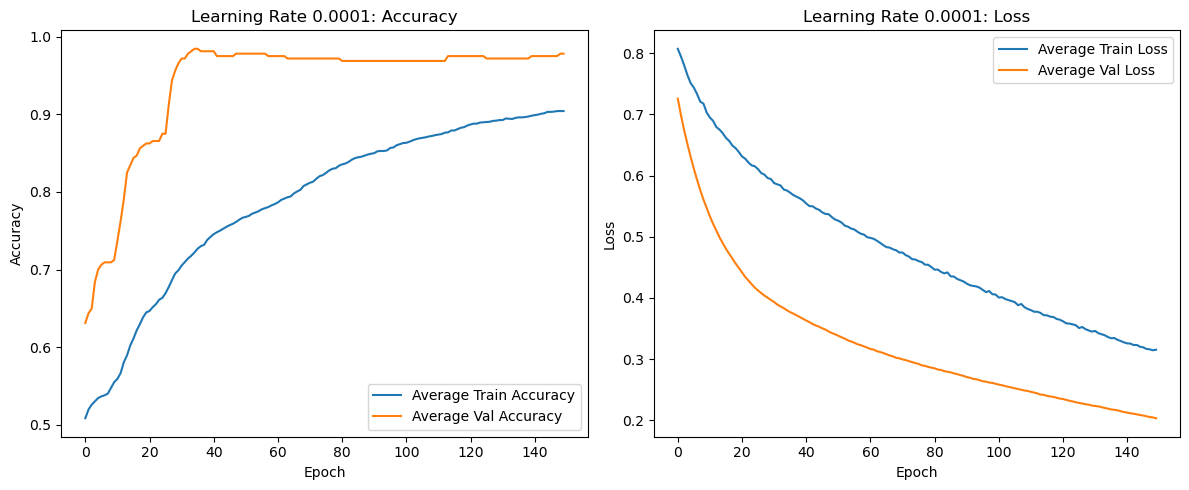

Training with learning rate: 0.001
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


KeyboardInterrupt: 

In [7]:
#Ionosphere

learning_rates = [0.0001, 0.001, 0.01]
final_accuracies0, final_F10 = [], []

for learning_rate in learning_rates:
    print(f"Training with learning rate: {learning_rate}")
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    accuracies, f1_scores = [], []

    # Initialize lists to collect metrics across all folds for averaging
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for train_index, test_index in kf.split(X2): 
        # Splitting the dataset
        X2_train, X2_test = X2[train_index], X2[test_index]
        y2_train, y2_test = y2[train_index], y2[test_index]

        # Model definition
        model = Sequential([
            Input(shape=(34,)),  
            Dense(12, activation='relu'),
            Dense(8, activation='relu'),
            Dense(1, activation='sigmoid')  # For binary classification
        ])
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

        # Training the model
        history = model.fit(X2_train, y2_train, validation_split=0.1, epochs=150, batch_size=10, verbose=0)

        _, accuracy = model.evaluate(X2_test, y2_test, verbose=0)
        predictions = (model.predict(X2_test) > 0.5).astype("int32")
        f1 = f1_score(y2_test, predictions, average='binary')

        accuracies.append(accuracy * 100)
        f1_scores.append(f1)

        # Collecting metrics
        train_accuracies.append(history.history['accuracy'])
        val_accuracies.append(history.history['val_accuracy'])
        train_losses.append(history.history['loss'])
        val_losses.append(history.history['val_loss'])

    # Averaging the metrics across all folds
    avg_train_acc = np.mean(train_accuracies, axis=0)
    avg_val_acc = np.mean(val_accuracies, axis=0)
    avg_train_loss = np.mean(train_losses, axis=0)
    avg_val_loss = np.mean(val_losses, axis=0)

    # Plotting averaged learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_acc, label='Average Train Accuracy')
    plt.plot(avg_val_acc, label='Average Val Accuracy')
    plt.title(f'Learning Rate {learning_rate}: Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(avg_train_loss, label='Average Train Loss')
    plt.plot(avg_val_loss, label='Average Val Loss')
    plt.title(f'Learning Rate {learning_rate}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    final_accuracies0.append(np.mean(accuracies))
    final_F10.append(np.mean(f1_scores))

# Summary statistics for all learning rates
print("Summary Across Learning Rates:")
print("Mean Accuracy:", np.mean(final_accuracies0))
print("Standard Deviation of Accuracy:", np.std(final_accuracies0))
print("Mean F1 Score:", np.mean(final_F10))
print("Standard Deviation of F1 Score:", np.std(final_F10))

Training with learning rate: 0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


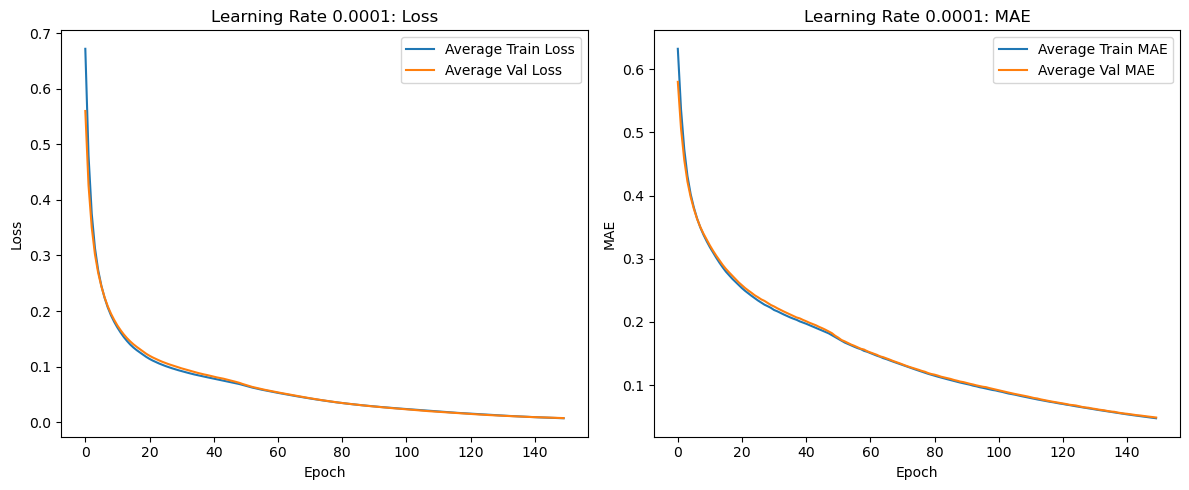

Training with learning rate: 0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


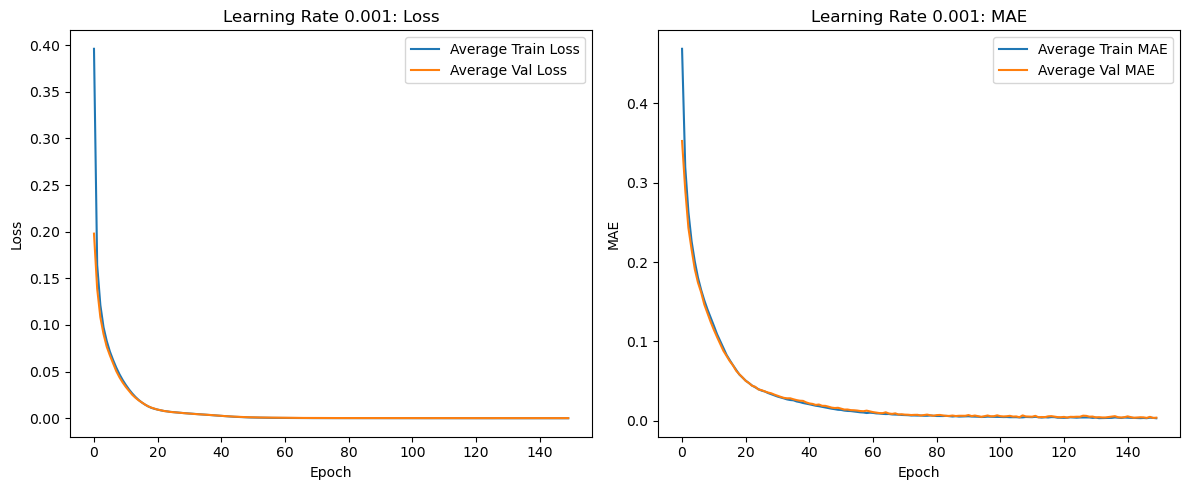

Training with learning rate: 0.01
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


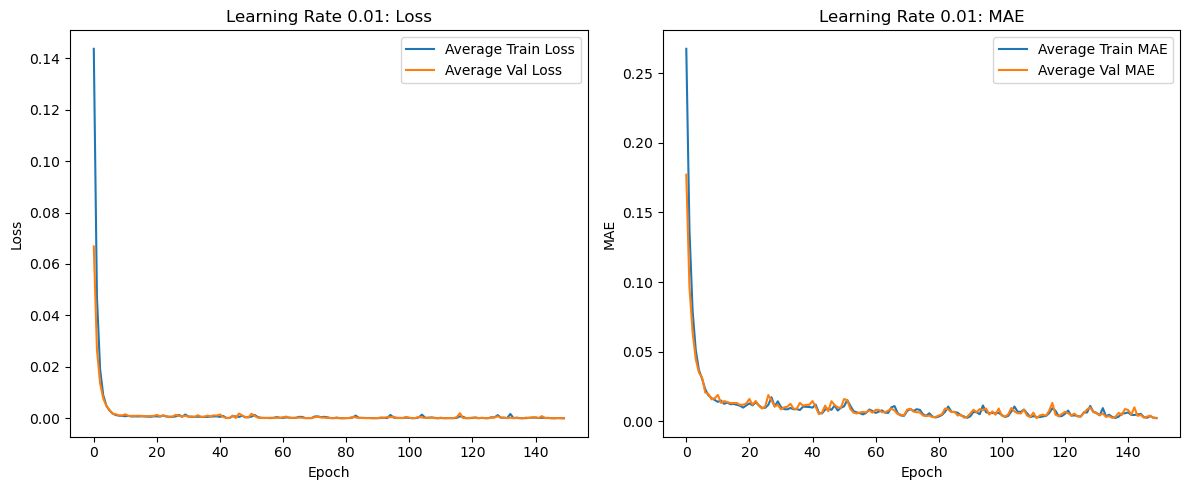

Final Metrics Across Learning Rates:
MSE: [0.007144390203548059, 0.00016017265644620212, 2.3918999239287783e-05]
MAE: [0.04862451019796553, 0.0036071329920050964, 0.0022704154243872706]
R2: [0.959120342099214, 0.9989811571682525, 0.9998655679219375]


In [10]:
#Solar Flare

#Mean Squared Error (MSE): 
#This is the average of the squared differences between the predicted values and the actual values.
#By squaring the differences, MSE gives more weight to larger errors. This means that a model with a lower MSE 
#is better at making predictions that are close to the true values, especially because it's more sensitive to large errors than MAE.
#Mean Absolute Error (MAE): How wrong predictions were on average- is ideally small 
#R² values range from 0 to 1, where 1 indicates that the model perfectly predicts the target variable, 
#and a value closer to 0 indicates that the model fails to accurately model the target variable.

#I changed these metrics from the accuracy that was used in the others because they are more appropriete for 
#the multi-class multi-label problem that this is. 

learning_rates = [0.0001, 0.001, 0.01]
final_mse, final_mae, final_r2 = [], [], []

for learning_rate in learning_rates:
    print(f"Training with learning rate: {learning_rate}")
    mse_scores, mae_scores, r2_scores = [], [], []
    
    # Lists to accumulate history for averaging
    train_losses = []
    val_losses = []
    train_maes = []
    val_maes = []

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    for train_index, test_index in kf.split(X3):
        X3_train, X3_test = X3[train_index], X3[test_index]
        y3_train, y3_test = y3[train_index], y3[test_index]

        model = Sequential([
            Input(shape=(26,)),
            Dense(12, activation='relu'),
            Dense(8, activation='relu'),
            Dense(3)  
        ])
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])

        history = model.fit(X3_train, y3_train, validation_data=(X3_test, y3_test), epochs=150, batch_size=10, verbose=0)

        predictions = model.predict(X3_test)
        mse_scores.append(mean_squared_error(y3_test, predictions))
        mae_scores.append(mean_absolute_error(y3_test, predictions))
        r2_scores.append(r2_score(y3_test, predictions))

        # Accumulate metrics for averaging
        train_losses.append(history.history['loss'])
        val_losses.append(history.history['val_loss'])
        train_maes.append(history.history['mae'])
        val_maes.append(history.history['val_mae'])

    # Averaging metrics across folds
    avg_train_loss = np.mean(train_losses, axis=0)
    avg_val_loss = np.mean(val_losses, axis=0)
    avg_train_mae = np.mean(train_maes, axis=0)
    avg_val_mae = np.mean(val_maes, axis=0)

    # Plotting the averaged learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_loss, label='Average Train Loss')
    plt.plot(avg_val_loss, label='Average Val Loss')
    plt.title(f'Learning Rate {learning_rate}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(avg_train_mae, label='Average Train MAE')
    plt.plot(avg_val_mae, label='Average Val MAE')
    plt.title(f'Learning Rate {learning_rate}: MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    final_mse.append(np.mean(mse_scores))
    final_mae.append(np.mean(mae_scores))
    final_r2.append(np.mean(r2_scores))

# Print aggregated metrics after all learning rates have been processed
print("Final Metrics Across Learning Rates:")
print("MSE:", final_mse)
print("MAE:", final_mae)
print("R2:", final_r2)